# Task 4 — Loan Approval Prediction

**Objectif :** prédire si une demande de prêt sera approuvée ou rejetée, à partir du profil du demandeur.

**Dataset :** Loan-Approval-Prediction-Dataset (Kaggle) — 4269 demandes, 13 colonnes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.over_sampling import SMOTE

plt.rcParams["figure.figsize"] = (8, 5)

## 1. Chargement et nettoyage des données

In [2]:
df = pd.read_csv("../data/loan_approval_dataset.csv")

# Les noms de colonnes ont des espaces parasites (ex: " education") -> on nettoie
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.info()
print()
print("Valeurs manquantes :", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB

Valeurs manquantes : 0


Les valeurs texte (`education`, `self_employed`, `loan_status`) ont aussi des espaces parasites au début — on nettoie pareil.

In [4]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

## 2. Distribution de la variable cible (déséquilibre des classes)

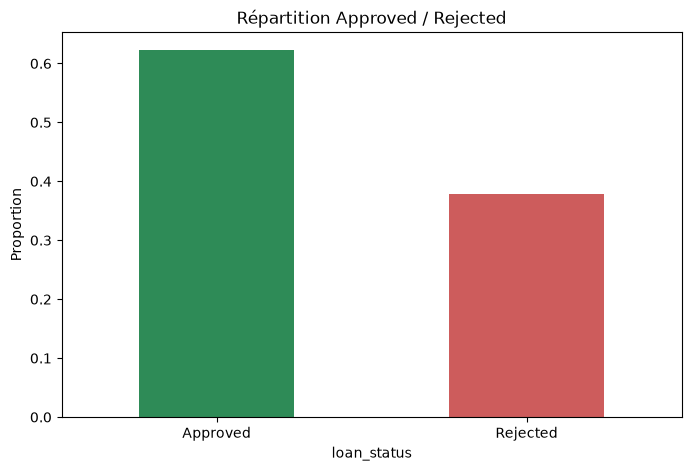

loan_status
Approved    0.622
Rejected    0.378
Name: proportion, dtype: float64


In [5]:
df["loan_status"].value_counts(normalize=True).plot(kind="bar", color=["seagreen", "indianred"])
plt.ylabel("Proportion")
plt.title("Répartition Approved / Rejected")
plt.xticks(rotation=0)
plt.savefig("../outputs/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

print(df["loan_status"].value_counts(normalize=True).round(3))

→ ~62 % Approved / 38 % Rejected. Ce n'est pas un déséquilibre extrême, mais suffisant pour qu'une accuracy seule soit trompeuse — c'est pour ça qu'on va se concentrer sur precision/recall/F1 plutôt que sur l'accuracy globale.

## 3. Encodage des variables catégorielles

In [6]:
df_encoded = df.drop(columns=["loan_id"]).copy()

le_education = LabelEncoder()
df_encoded["education"] = le_education.fit_transform(df_encoded["education"])

le_employed = LabelEncoder()
df_encoded["self_employed"] = le_employed.fit_transform(df_encoded["self_employed"])

le_target = LabelEncoder()
df_encoded["loan_status"] = le_target.fit_transform(df_encoded["loan_status"])

print("Classes loan_status :", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
df_encoded.head()

Classes loan_status : {'Approved': np.int64(0), 'Rejected': np.int64(1)}


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## 4. Split train/test

In [7]:
X = df_encoded.drop(columns=["loan_status"])
y = df_encoded["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (3415, 11)  Test: (854, 11)


## 5. Modèle de base — Régression logistique

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

              precision    recall  f1-score   support

    Approved       0.93      0.95      0.94       531
    Rejected       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



## 6. Matrice de confusion

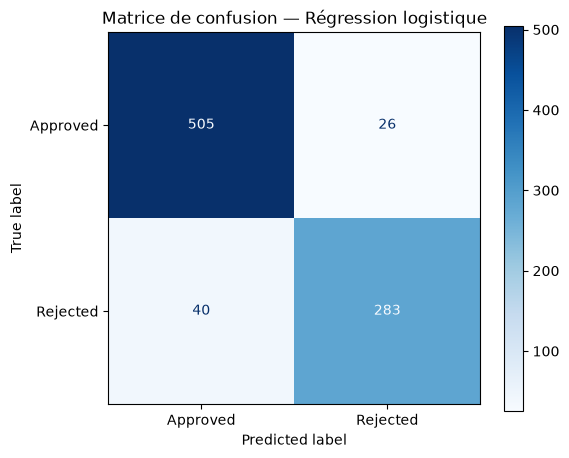

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Matrice de confusion — Régression logistique")
plt.savefig("../outputs/02_confusion_matrix_logreg.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Logistic Regression vs Decision Tree

In [10]:
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)  # les arbres n'ont pas besoin de scaling
y_pred_tree = tree.predict(X_test)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_tree, target_names=le_target.classes_))

comparison = pd.DataFrame({
    "Modèle": ["Logistic Regression", "Decision Tree"],
    "F1 (Rejected)": [
        f1_score(y_test, y_pred_lr, pos_label=0),
        f1_score(y_test, y_pred_tree, pos_label=0),
    ],
    "F1 (Approved)": [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1),
    ],
})
comparison

=== Decision Tree ===
              precision    recall  f1-score   support

    Approved       0.96      0.99      0.98       531
    Rejected       0.99      0.93      0.96       323

    accuracy                           0.97       854
   macro avg       0.98      0.96      0.97       854
weighted avg       0.97      0.97      0.97       854



,Modèle,F1 (Rejected),F1 (Approved)
0,Logistic Regression,0.938662,0.895570
1,Decision Tree,0.977778,0.961783


## 8. SMOTE pour rééquilibrer les classes

SMOTE crée des exemples synthétiques de la classe minoritaire (`Rejected`) dans le jeu d'entraînement, pour que le modèle ne soit pas biaisé vers la classe majoritaire.

In [11]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts().to_dict())
print("Après SMOTE :", y_train_smote.value_counts().to_dict())

Avant SMOTE : {0: 2125, 1: 1290}
Après SMOTE : {1: 2125, 0: 2125}


In [12]:
scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_scaled_2 = scaler_smote.transform(X_test)

log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote_scaled, y_train_smote)
y_pred_smote = log_reg_smote.predict(X_test_scaled_2)

print("=== Logistic Regression + SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=le_target.classes_))

=== Logistic Regression + SMOTE ===
              precision    recall  f1-score   support

    Approved       0.94      0.94      0.94       531
    Rejected       0.91      0.90      0.91       323

    accuracy                           0.93       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.93      0.93      0.93       854



## 9. Comparaison finale

In [13]:
final_comparison = pd.DataFrame({
    "Approche": ["Logistic Regression (base)", "Decision Tree", "Logistic Regression + SMOTE"],
    "F1 (Rejected)": [
        f1_score(y_test, y_pred_lr, pos_label=0),
        f1_score(y_test, y_pred_tree, pos_label=0),
        f1_score(y_test, y_pred_smote, pos_label=0),
    ],
    "F1 (Approved)": [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1),
        f1_score(y_test, y_pred_smote, pos_label=1),
    ],
})
final_comparison

,Approche,F1 (Rejected),F1 (Approved)
0,Logistic Regression (base),0.938662,0.895570
1,Decision Tree,0.977778,0.961783
2,Logistic Regression + SMOTE,0.942615,0.905426


## 10. Feature importance (Decision Tree)

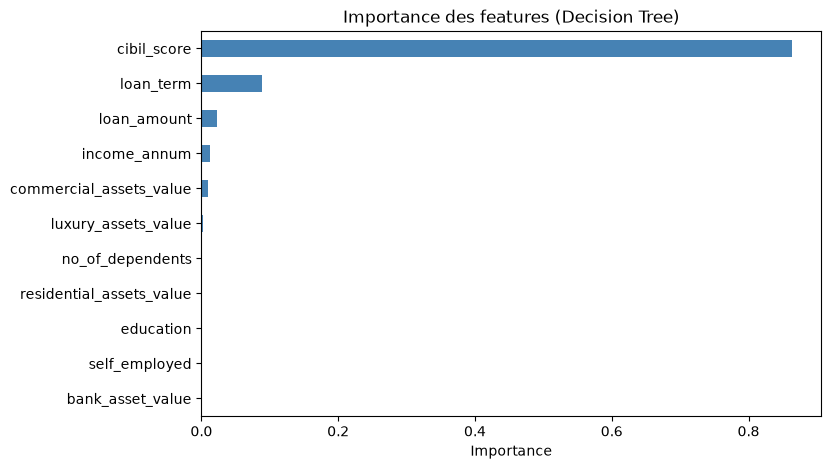

In [14]:
importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Importance des features (Decision Tree)")
plt.savefig("../outputs/03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Prochaine étape possible :** tester un modèle d'ensemble (Random Forest, XGBoost) pour voir si ça dépasse encore la régression logistique et l'arbre de décision simple.